# Анализ процесса регистрации клиентов (физлиц) в отделениях банка

## Описание задачи
Анализ данных по событиям в системе регистрации новых клиентов за первые 7 месяцев 2024 года.

**Цель:** Показать динамику процесса, выявить проблемные зоны, оценить изменения за период.

## 1. Импорт библиотек и загрузка данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Настройка визуализации
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

# Для корректного отображения русских символов
plt.rcParams['font.family'] = 'DejaVu Sans'

print("Библиотеки загружены успешно")

Библиотеки загружены успешно


In [2]:
# Загрузка данных с обработкой кодировки и разделителя
# Пробуем разные кодировки для корректного чтения файла
encodings = ['utf-8', 'cp1251', 'latin-1', 'iso-8859-1']
separators = [';', ',', '\t']
df = None

for encoding in encodings:
    for sep in separators:
        try:
            df = pd.read_csv('dataset.csv', encoding=encoding, sep=sep, low_memory=False)
            # Проверяем, что файл правильно распарсился (должно быть больше 1 колонки)
            if df.shape[1] > 1:
                print(f"Файл успешно загружен с кодировкой: {encoding}, разделитель: '{sep}'")
                break
        except UnicodeDecodeError:
            continue
        except Exception as e:
            continue
    if df is not None and df.shape[1] > 1:
        break

if df is None or df.shape[1] == 1:
    # Если все кодировки не подошли, пробуем с errors='ignore'
    print("Пробуем загрузить с игнорированием ошибок кодировки...")
    for sep in separators:
        try:
            df = pd.read_csv('dataset.csv', encoding='utf-8', errors='ignore', sep=sep, low_memory=False)
            if df.shape[1] > 1:
                print(f"Файл загружен с разделителем: '{sep}'")
                break
        except:
            continue

# Приводим названия колонок к нижнему регистру и убираем лишние символы
df.columns = df.columns.str.lower().str.strip().str.replace('"', '').str.replace("'", "")

print(f"\nРазмер датасета: {df.shape}")
print(f"\nКолонки: {df.columns.tolist()}")
print(f"\nПервые строки:")
df.head()

Файл успешно загружен с кодировкой: cp1251, разделитель: ';'

Размер датасета: (4401659, 7)

Колонки: ['timestamp', 'timestamp_day', 'employee_id', 'case_id', 'event_category', 'event_name', 'event_property']

Первые строки:


,timestamp,timestamp_day,employee_id,case_id,event_category,event_name,event_property
0,"11.01.24 14:57:19,646000",11.01.2024,2167193964,659fd71c83c9203126a7e90a,summary,Submit > Response,NaN
1,"11.01.24 17:05:40,014000",11.01.2024,2167193964,659ff53053858648a60d861a,summary,Submit > Response,NaN
2,"11.01.24 07:06:10,261000",11.01.2024,3712217667,659f67076743b31d8bbf7001,summary,Submit > Response,NaN
3,"11.01.24 13:09:54,309000",11.01.2024,3712217667,659fbdd9232ba543279bc860,summary,Submit > Response,NaN
4,"11.01.24 12:04:31,848000",11.01.2024,1427323230,659fae3383c9203126a7e861,summary,Submit > Response,NaN


In [3]:
# Диагностика полей timestamp
print('timestamp dtype:', df['timestamp'].dtype)
print('timestamp_day dtype:', df['timestamp_day'].dtype)
print('\nПримеры значений timestamp (первые 20):')
print(df['timestamp'].head(20).to_string())

print('\nТипы значений в колонке timestamp:')
print(df['timestamp'].apply(lambda x: type(x)).value_counts())

# Проверка длины строк в timestamp
s = df['timestamp'].astype(str)
lens = s.str.len()
print('\nМаксимальная длина строки в timestamp:', lens.max())
print('Примеры очень длинных значений (больше 100 символов):')
print(s[lens > 100].head(10).to_string())

print('\nУникальных значений (не NaN):', df['timestamp'].nunique(dropna=True))

# То же для timestamp_day
print('\n--- timestamp_day ---')
print('dtype:', df['timestamp_day'].dtype)
print(df['timestamp_day'].head(20).to_string())
print(df['timestamp_day'].apply(lambda x: type(x)).value_counts())
print('\nУникальных значений timestamp_day (не NaN):', df['timestamp_day'].nunique(dropna=True))

timestamp dtype: object
timestamp_day dtype: object

Примеры значений timestamp (первые 20):
0     11.01.24 14:57:19,646000
1     11.01.24 17:05:40,014000
2     11.01.24 07:06:10,261000
3     11.01.24 13:09:54,309000
4     11.01.24 12:04:31,848000
5     11.01.24 14:31:05,843000
6     11.01.24 10:35:20,753000
7     11.01.24 12:25:51,257000
8     11.01.24 17:55:23,988000
9     11.01.24 13:46:59,536000
10    11.01.24 16:17:37,866000
11    11.01.24 17:34:47,602000
12    11.01.24 19:29:55,015000
13    10.01.24 13:30:43,812000
14    10.01.24 15:23:32,352000
15    10.01.24 17:41:43,566000
16    10.01.24 18:21:56,074000
17    10.01.24 19:36:44,326000
18    10.01.24 06:56:03,161000
19    10.01.24 07:44:22,957000

Типы значений в колонке timestamp:
timestamp
<class 'str'>    4401659
Name: count, dtype: int64

Максимальная длина строки в timestamp: 24
Примеры очень длинных значений (больше 100 символов):
Series([], )

Уникальных значений (не NaN): 4400211

--- timestamp_day ---
dtype: object
0   

In [4]:
# Преобразование timestamp (оптимизировано с явными форматами для ускорения)
# Сохраним оригинальные значения на случай отката
orig_ts = df['timestamp'].copy()

# Сначала парсим timestamp_day (формат DD.MM.YYYY)
df['timestamp_day'] = pd.to_datetime(df['timestamp_day'], format='%d.%m.%Y', errors='coerce')

# Парсим timestamp с известным форматом 'DD.MM.YY HH:MM:SS,ffffff'
# Это существенно быстрее, чем универсальный парсер для больших фреймов
df['timestamp'] = pd.to_datetime(df['timestamp'], format='%d.%m.%y %H:%M:%S,%f', errors='coerce')

# Фоллбек: для оставшихся элементов попробуем заменить ',' на '.' и распарсить другой формойатом
fallback_mask = df['timestamp'].isna() & orig_ts.notna()
if fallback_mask.any():
    fallback_series = orig_ts.loc[fallback_mask].astype(str).str.replace(',', '.', regex=False)
    df.loc[fallback_mask, 'timestamp'] = pd.to_datetime(fallback_series, format='%d.%m.%y %H:%M:%S.%f', errors='coerce')

# Удаляем строки с некорректными датами
missing_before = df.shape[0]
df = df.dropna(subset=['timestamp', 'timestamp_day']).copy()
missing_after = df.shape[0]
print(f"Rows removed due to bad dates: {missing_before - missing_after}")

# Добавление месяца для группировки
df['month'] = df['timestamp_day'].dt.to_period('M')
df['month_str'] = df['timestamp_day'].dt.strftime('%Y-%m')

print(f"Период данных: {df['timestamp_day'].min()} - {df['timestamp_day'].max()}")
print(f"\nУникальные месяцы: {sorted(df['month_str'].unique())}")
print(f"\nУникальные event_category: {df['event_category'].unique()}")

df.info()

Rows removed due to bad dates: 0
Период данных: 2024-01-04 00:00:00 - 2024-07-31 00:00:00

Уникальные месяцы: ['2024-01', '2024-02', '2024-03', '2024-04', '2024-05', '2024-06', '2024-07']

Уникальные event_category: ['summary' 'employment' 'nonResidentInfo' 'questionnaire' 'main' 'cards'
 'contacts' 'servicePackage' 'taxResidentInfo' 'docsUpload' 'addresses'
 'identification' 'confirm' 'result' 'accessCard' 'session'
 'cardsDelivery']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4401659 entries, 0 to 4401658
Data columns (total 9 columns):
 #   Column          Dtype         
---  ------          -----         
 0   timestamp       datetime64[ns]
 1   timestamp_day   datetime64[ns]
 2   employee_id     int64         
 3   case_id         object        
 4   event_category  object        
 5   event_name      object        
 6   event_property  object        
 7   month           period[M]     
 8   month_str       object        
dtypes: datetime64[ns](2), int64(1), object(5), perio

## 2. Подготовка данных и справочники

In [5]:
# Справочник основных экранных форм
steps_dict = {
    'main': {'name': 'Персональные данные', 'order': 1},
    'identification': {'name': 'Идентификация паспортных данных', 'order': 2},
    'taxResidentInfo': {'name': 'Резидент или информация о нерезиденте', 'order': 3},
    'addresses': {'name': 'Адреса', 'order': 4},
    'employment': {'name': 'Занятость', 'order': 5},
    'contacts': {'name': 'Контактная информация', 'order': 6},
    'servicePackage': {'name': 'ПУ и счета', 'order': 7},
    'cards': {'name': 'Заказ именных карт', 'order': 8},
    'accessCard': {'name': 'Моментальная выдача карты', 'order': 9},
    'summary': {'name': 'Проверка данных и подписание черновика', 'order': 10},
    'questionnaire': {'name': 'Подписание анкеты', 'order': 11},
    'docsUpload': {'name': 'Прикрепление документов', 'order': 12}
}

steps_df = pd.DataFrame([
    {'step_id': k, 'step_name': v['name'], 'step_order': v['order']}
    for k, v in steps_dict.items()
]).sort_values('step_order')

print("Справочник экранных форм:")
steps_df

Справочник экранных форм:


,step_id,step_name,step_order
0,main,Персональные данные,1
1,identification,Идентификация паспортных данных,2
2,taxResidentInfo,Резидент или информация о нерезиденте,3
3,addresses,Адреса,4
4,employment,Занятость,5
5,contacts,Контактная информация,6
6,servicePackage,ПУ и счета,7
7,cards,Заказ именных карт,8
8,accessCard,Моментальная выдача карты,9
9,summary,Проверка данных и подписание черновика,10


In [6]:
# Определение успешных регистраций
successful_cases = df[
    (df['event_category'] == 'result') & 
    (df['event_name'] == 'Submit > Response')
]['case_id'].unique()

print(f"Количество успешных регистраций: {len(successful_cases)}")

Количество успешных регистраций: 126154


In [28]:
# Векторизированный расчёт времени УСПЕШНЫХ регистраций
# Время начала (session)
session_times = df[df['event_category'] == 'session'].groupby('case_id')['timestamp'].min()

# Время завершения (только успешные result)
result_times = df[
    (df['event_category'] == 'result') & 
    (df['event_name'] == 'Submit > Response')
].groupby('case_id')['timestamp'].max()

# Объединяем и вычисляем длительность
times_df = pd.DataFrame({'start': session_times, 'end': result_times}).dropna()
times_df['duration_minutes'] = (times_df['end'] - times_df['start']).dt.total_seconds() / 60.0

# Берём месяц из успешных result-событий
result_months = df[
    (df['event_category'] == 'result') & 
    (df['event_name'] == 'Submit > Response')
].drop_duplicates('case_id').set_index('case_id')['month_str']
times_df['month'] = result_months.reindex(times_df.index)

case_times_df = times_df.reset_index().rename(columns={'index': 'case_id'})


# Исключение выбросов (>30 минут)
case_times_df_filtered = case_times_df[case_times_df['duration_minutes'] <= 30].copy()


## Задание 1: Динамика успешных регистраций и среднего времени процесса

In [8]:
monthly_stats = case_times_df_filtered.groupby('month').agg({
    'case_id': 'count',
    'duration_minutes': 'mean'
}).reset_index()
monthly_stats.columns = ['month', 'successful_registrations', 'avg_duration_minutes']
monthly_stats = monthly_stats.sort_values('month')

print("Динамика по месяцам:")
print(monthly_stats.to_string(index=False))

Динамика по месяцам:
  month  successful_registrations  avg_duration_minutes
2024-01                     14295              6.945129
2024-02                     16865              6.973072
2024-03                     18021              6.903166
2024-04                     18230              6.867911
2024-05                     19203              6.802345
2024-06                     18297              6.869433
2024-07                     20831              6.893615


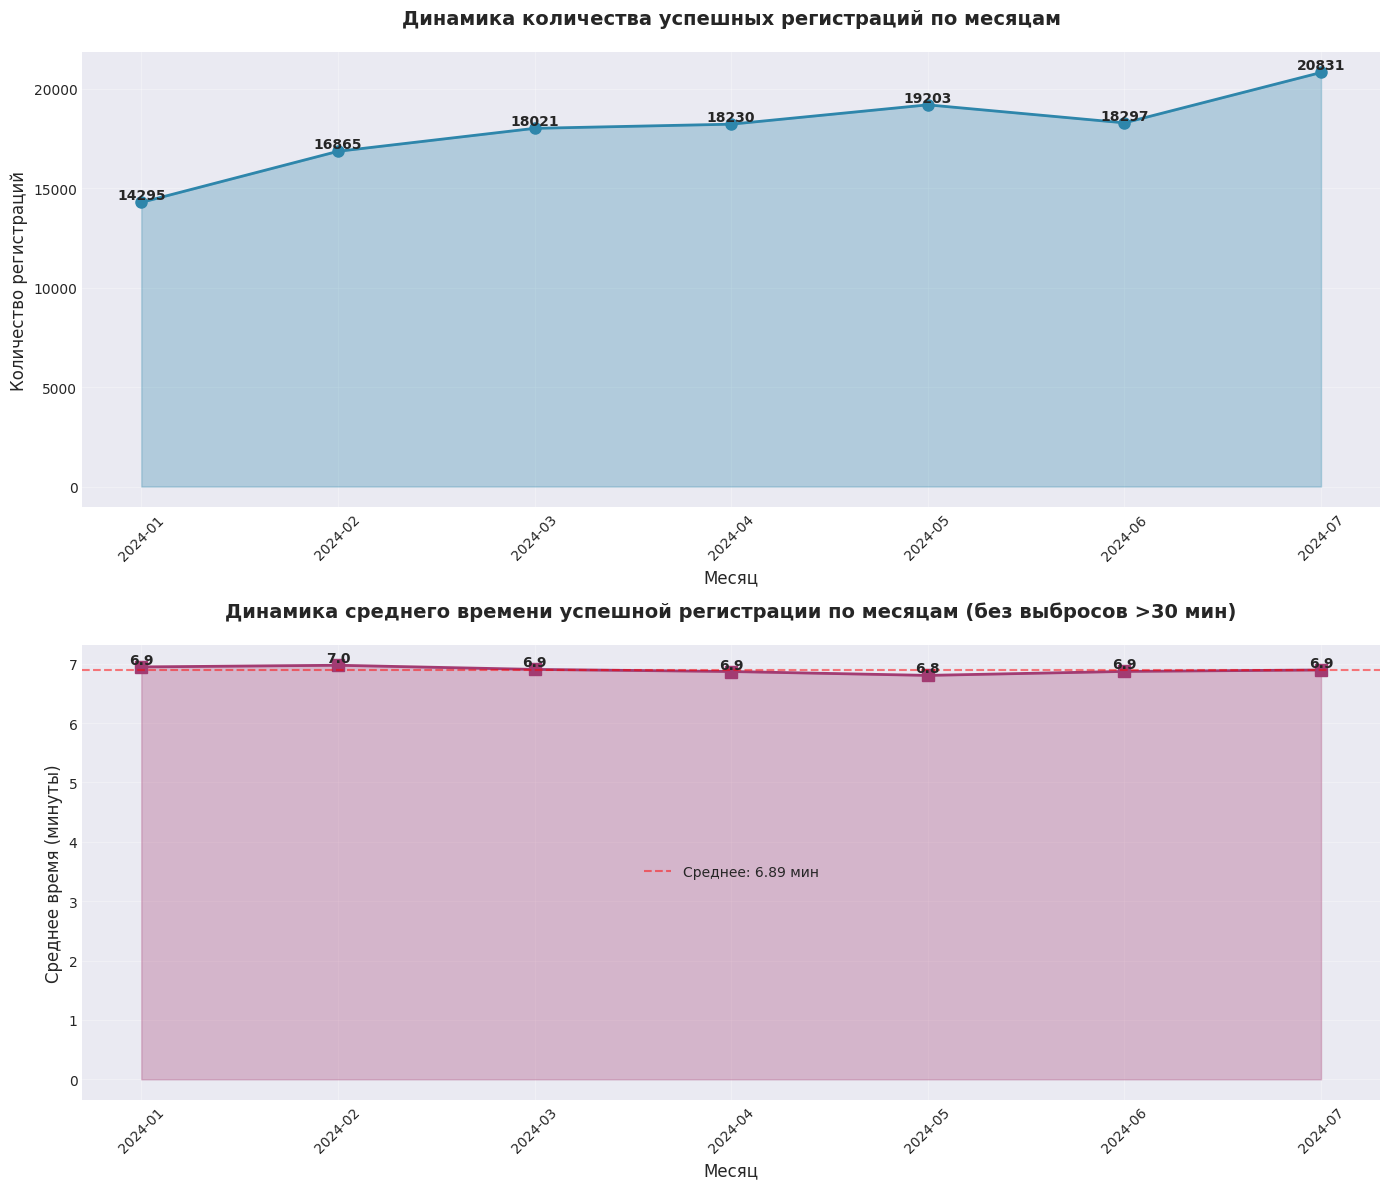

In [27]:
# Визуализация задания 1
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

months = monthly_stats['month'].astype(str)
regs = monthly_stats['successful_registrations'].values
times = monthly_stats['avg_duration_minutes'].values

# График 1: Количество успешных регистраций
ax1.plot(months, regs, marker='o', linewidth=2, markersize=8, color='#2E86AB')
ax1.fill_between(range(len(months)), regs, alpha=0.3, color='#2E86AB')
ax1.set_xticks(range(len(months)))
ax1.set_xticklabels(months, rotation=45)
ax1.set_title('Динамика количества успешных регистраций по месяцам', fontsize=14, fontweight='bold', pad=20)
ax1.set_xlabel('Месяц', fontsize=12)
ax1.set_ylabel('Количество регистраций', fontsize=12)
ax1.grid(True, alpha=0.3)

for i, value in enumerate(regs):
    ax1.text(i, value, f'{int(value)}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# График 2: Среднее время процесса
ax2.plot(months, times, marker='s', linewidth=2, markersize=8, color='#A23B72')
ax2.fill_between(range(len(months)), times, alpha=0.3, color='#A23B72')
ax2.set_xticks(range(len(months)))
ax2.set_xticklabels(months, rotation=45)
ax2.set_title('Динамика среднего времени успешной регистрации по месяцам (без выбросов >30 мин)', 
              fontsize=14, fontweight='bold', pad=20)
ax2.set_xlabel('Месяц', fontsize=12)
ax2.set_ylabel('Среднее время (минуты)', fontsize=12)
ax2.grid(True, alpha=0.3)

# Добавляем среднюю линию
avg_all = times.mean()
ax2.axhline(y=avg_all, color='red', linestyle='--', alpha=0.5, label=f'Среднее: {avg_all:.2f} мин')
ax2.legend()

for i, value in enumerate(times):
    ax2.text(i, value, f'{value:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()



## Задание 2: Детализация времени по экранным формам

In [32]:
steps_keys = sorted(steps_dict.keys(), key=lambda x: steps_dict[x]['order'])

optional_to_main_mapping = {
    'cardsDelivery': 'cards',      # Оформление доставки → Заказ именных карт
    'nonResidentInfo': 'taxResidentInfo',  # Информация о нерезидентах → Налоговое резидентство
    'confirm': 'summary'            # Подтверждение кодом из СМС → Проверка данных и подписание
}
all_form_categories = list(steps_keys) + list(optional_to_main_mapping.keys())

print("Основные формы (12 шт):", steps_keys)
print("\nОпциональные формы и их связь с основными:")
for opt, main in optional_to_main_mapping.items():
    print(f"  {opt} → {main}")

Основные формы (12 шт): ['main', 'identification', 'taxResidentInfo', 'addresses', 'employment', 'contacts', 'servicePackage', 'cards', 'accessCard', 'summary', 'questionnaire', 'docsUpload']

Опциональные формы и их связь с основными:
  cardsDelivery → cards
  nonResidentInfo → taxResidentInfo
  confirm → summary


In [33]:
def calculate_step_times_correct(df, case_times_filtered):
  
    
    # Берем только успешные регистрации без выбросов
    valid_cases = set(case_times_filtered['case_id'])
    
    # Фильтруем события: только нужные формы и валидные case_id
    events = df[
        (df['case_id'].isin(valid_cases)) &
        (df['event_category'].isin(all_form_categories))
    ].copy()
    
    # Добавляем информацию о границах процесса
    case_bounds = case_times_filtered.set_index('case_id')[['start', 'end']]
    events = events.merge(case_bounds, left_on='case_id', right_index=True, how='inner')
    
    # Оставляем только события внутри процесса регистрации
    events = events[
        (events['timestamp'] >= events['start']) & 
        (events['timestamp'] <= events['end'])
    ].copy()
    
    # Сортируем по case_id и времени
    events = events.sort_values(['case_id', 'timestamp']).reset_index(drop=True)
    
    # Определяем следующее событие для каждой строки
    events['next_timestamp'] = events.groupby('case_id')['timestamp'].shift(-1)
    events['next_category'] = events.groupby('case_id')['event_category'].shift(-1)
    
    # Время на форме = время до следующего события (если следующее событие есть)
    events['time_on_step_minutes'] = (
        (events['next_timestamp'] - events['timestamp']).dt.total_seconds() / 60.0
    )
    
    # Для последнего события в case_id ставим 0
    events['time_on_step_minutes'] = events['time_on_step_minutes'].fillna(0)
    
    # Убираем отрицательные значения (если есть)
    events.loc[events['time_on_step_minutes'] < 0, 'time_on_step_minutes'] = 0
    
    # Маппинг опциональных форм к основным
    events['main_category'] = events['event_category'].map(
        lambda x: optional_to_main_mapping.get(x, x)
    )
    
    # Суммируем время по case_id и основным формам
    # (время опциональных форм автоматически прибавится к основным)
    step_times = events.groupby(['case_id', 'main_category'])['time_on_step_minutes'].sum().reset_index()
    
    # Pivot: строки = case_id, колонки = step_id
    step_pivot = step_times.pivot(
        index='case_id', 
        columns='main_category', 
        values='time_on_step_minutes'
    )
    
    # Убедимся, что все 12 основных форм присутствуют
    step_pivot = step_pivot.reindex(columns=steps_keys, fill_value=0)
    
    # Добавляем информацию о месяце и общем времени
    result = case_times_filtered[['case_id', 'duration_minutes', 'month']].merge(
        step_pivot.reset_index(),
        on='case_id',
        how='left'
    )
    
    # Заполняем NaN нулями (если какой-то формы не было вообще)
    result[steps_keys] = result[steps_keys].fillna(0)
    
    return result


step_times_df = calculate_step_times_correct(df, case_times_df_filtered)

print(f"\nРассчитано для {len(step_times_df)} успешных регистраций (без выбросов)")


Рассчитано для 125742 успешных регистраций (без выбросов)


In [34]:
# Шаг 4: Расчет средних значений по месяцам

print("СРЕДНЕЕ ВРЕМЯ ПО ФОРМАМ ПО МЕСЯЦАМ")


# Средние значения по каждой форме по месяцам
monthly_step_times = step_times_df.groupby('month')[steps_keys].mean().reset_index()

# Добавляем общее среднее время процесса
monthly_avg_total = step_times_df.groupby('month')['duration_minutes'].mean().reset_index()
monthly_step_times = monthly_step_times.merge(monthly_avg_total, on='month')

# Проверка сходимости на уровне месяцев
monthly_step_times['sum_steps'] = monthly_step_times[steps_keys].sum(axis=1)
monthly_step_times['difference'] = monthly_step_times['sum_steps'] - monthly_step_times['duration_minutes']

# Округляем для читаемости
for col in steps_keys + ['duration_minutes', 'sum_steps', 'difference']:
    monthly_step_times[col] = monthly_step_times[col].round(2)

print("\nСредние значения по месяцам:")
print(monthly_step_times.to_string(index=False))

СРЕДНЕЕ ВРЕМЯ ПО ФОРМАМ ПО МЕСЯЦАМ

Средние значения по месяцам:
  month  main  identification  taxResidentInfo  addresses  employment  contacts  servicePackage  cards  accessCard  summary  questionnaire  docsUpload  duration_minutes  sum_steps  difference
2024-01  0.39            0.17             0.63       0.53        0.08      0.16            0.53   0.33        0.38     1.46            0.0        1.60              6.95       6.27       -0.68
2024-02  0.39            0.18             0.64       0.54        0.08      0.17            0.53   0.30        0.35     1.49            0.0        1.63              6.97       6.31       -0.66
2024-03  0.40            0.18             0.70       0.54        0.08      0.17            0.35   0.30        0.29     1.54            0.0        1.71              6.90       6.25       -0.65
2024-04  0.41            0.17             0.71       0.51        0.08      0.24            0.18   0.31        0.20     1.56            0.0        1.86              6.8

In [35]:

# Задание 2: Проверка сходимости - детальная таблица по месяцам

# Создаем таблицу сходимости по месяцам
monthly_reconciliation = monthly_step_times[['month', 'duration_minutes', 'sum_steps', 'difference']].copy()
monthly_reconciliation['difference_pct'] = (
    (monthly_reconciliation['difference'] / monthly_reconciliation['duration_minutes'] * 100)
    .round(2)
)
monthly_reconciliation.columns = ['Месяц', 'Общее время (мин)', 'Сумма по формам (мин)', 'Разница (мин)', 'Разница (%)']

print("\nТаблица сходимости по месяцам:")
print(monthly_reconciliation.to_string(index=False))




Таблица сходимости по месяцам:
  Месяц  Общее время (мин)  Сумма по формам (мин)  Разница (мин)  Разница (%)
2024-01               6.95                   6.27          -0.68        -9.78
2024-02               6.97                   6.31          -0.66        -9.47
2024-03               6.90                   6.25          -0.65        -9.42
2024-04               6.87                   6.25          -0.62        -9.02
2024-05               6.80                   6.19          -0.61        -8.97
2024-06               6.87                   6.28          -0.59        -8.59
2024-07               6.89                   6.29          -0.61        -8.85


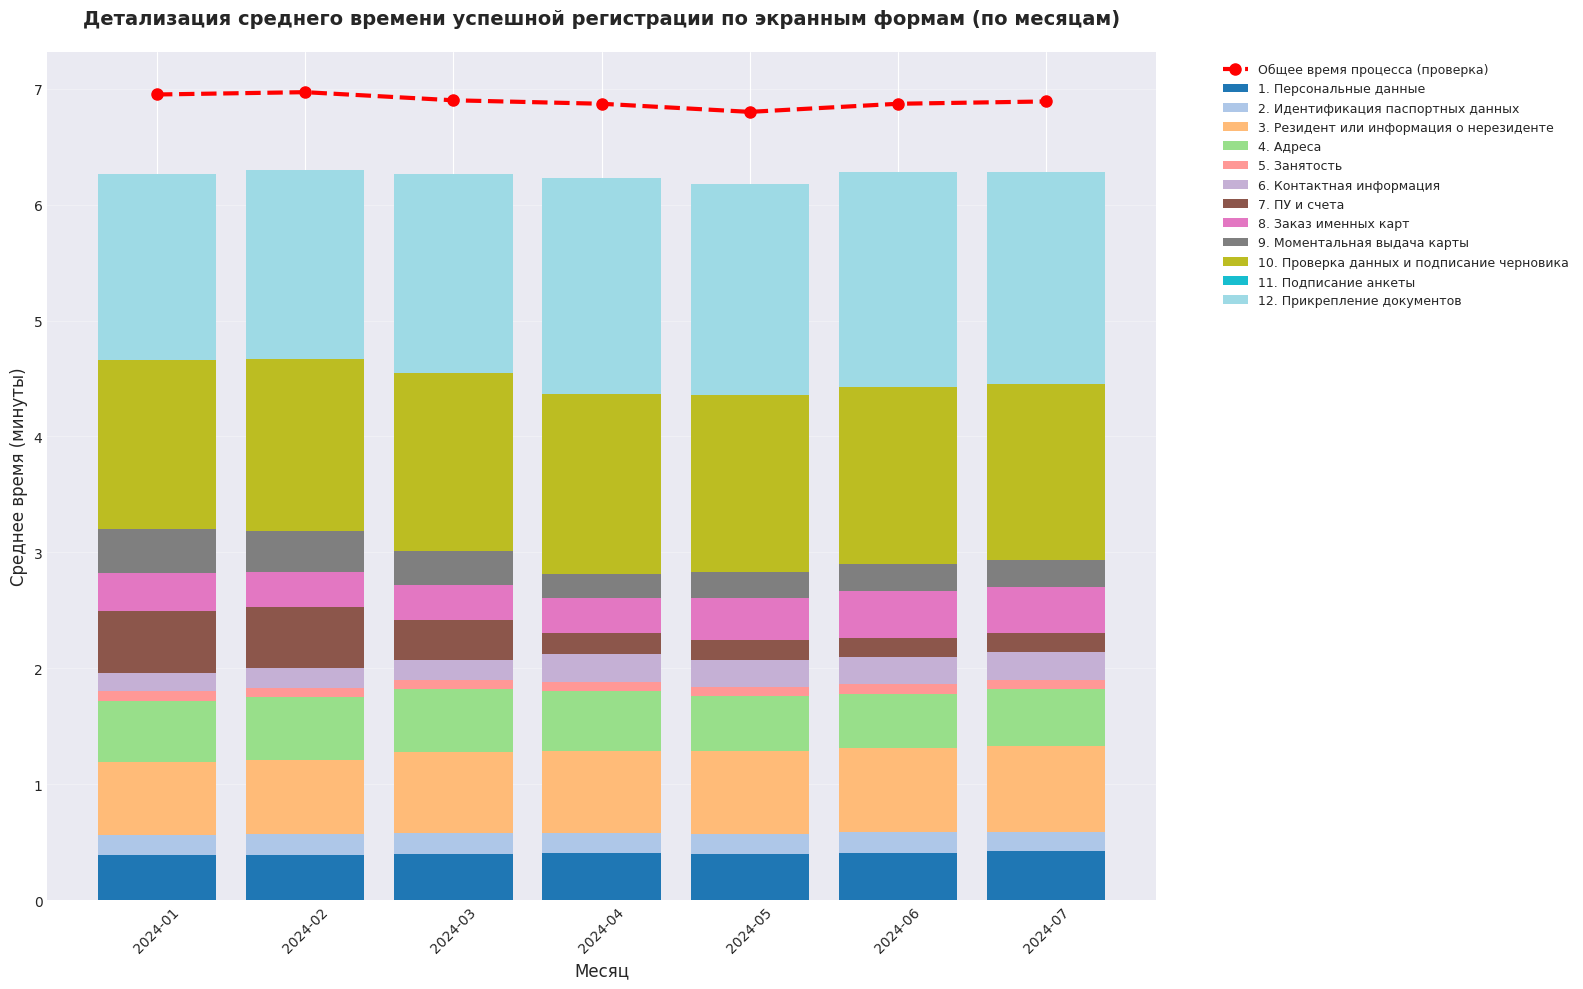

In [40]:
# Подготовка данных для stacked bar chart
months_str = monthly_step_times['month'].astype(str)
step_data = monthly_step_times[steps_keys].values.T  # Транспонируем для stacked bar

# Создаем цветовую палитру
colors = plt.cm.tab20(np.linspace(0, 1, 12))

fig, ax = plt.subplots(figsize=(16, 10))

# Stacked bar chart
bottom = np.zeros(len(months_str))
bars = []
for i, step_id in enumerate(steps_keys):
    step_name = steps_dict[step_id]['name']
    bar = ax.bar(months_str, step_data[i], bottom=bottom, 
                 label=f"{steps_dict[step_id]['order']}. {step_name}", 
                 color=colors[i])
    bars.append(bar)
    bottom += step_data[i]

# Добавляем линию общего времени процесса
ax.plot(months_str, monthly_step_times['duration_minutes'], 
        color='red', linewidth=3, marker='o', markersize=8,
        label='Общее время процесса (проверка)', linestyle='--')

# Настройка графика
ax.set_title('Детализация среднего времени успешной регистрации по экранным формам (по месяцам)', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Месяц', fontsize=12)
ax.set_ylabel('Среднее время (минуты)', fontsize=12)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Задание 3: Дополнительные метрики для отслеживания

In [61]:
# 1. Конверсия (процент успешных регистраций от всех начатых)
all_cases = df['case_id'].nunique()
successful_cases_count = len(successful_cases)
conversion_rate = (successful_cases_count / all_cases) * 100

print("1. КОНВЕРСИЯ (процент успешных регистраций)")
print(f"   Всего начатых регистраций: {all_cases}")
print(f"   Успешных регистраций: {successful_cases_count}")
print(f"   Конверсия: {conversion_rate:.2f}%")

# Конверсия по месяцам
monthly_conversion = []
for month in sorted(df['month_str'].unique()):
    month_cases = df[df['month_str'] == month]['case_id'].nunique()
    month_successful = df[(df['month_str'] == month) & (df['event_category'] == 'result')]['case_id'].nunique()
    conv = (month_successful / month_cases * 100) if month_cases > 0 else 0
    monthly_conversion.append({'month': month, 'conversion_rate': conv, 
                              'total_cases': month_cases, 'successful_cases': month_successful})

monthly_conversion_df = pd.DataFrame(monthly_conversion)
print(f"\n   Конверсия по месяцам:")
print(monthly_conversion_df.to_string(index=False))

1. КОНВЕРСИЯ (процент успешных регистраций)
   Всего начатых регистраций: 131858
   Успешных регистраций: 126154
   Конверсия: 95.67%

   Конверсия по месяцам:
  month  conversion_rate  total_cases  successful_cases
2024-01        95.484816        15016             14338
2024-02        95.214503        17762             16912
2024-03        95.600444        18911             18079
2024-04        95.716975        19122             18303
2024-05        96.247064        20011             19260
2024-06        95.169232        19293             18361
2024-07        96.127489        21743             20901


In [62]:
# 2. Количество возвратов на предыдущие формы (векторизованно, без циклов по case_id)
# Берём события только по экранным формам и только для успешных регистрации без выбросов
step_events_for_returns = df[df['event_category'].isin(steps_dict.keys()) & df['case_id'].isin(case_times_df_filtered['case_id'])].copy()

# Сортируем и вычисляем порядковый номер шага
step_events_for_returns = step_events_for_returns.sort_values(['case_id', 'timestamp'])
step_events_for_returns['step_order'] = step_events_for_returns['event_category'].map(lambda x: steps_dict[x]['order'])

# Сдвиг порядков внутри case_id для сравнения
step_events_for_returns['prev_order'] = step_events_for_returns.groupby('case_id')['step_order'].shift(1)
# Пометка возврата, если текущий шаг имеет меньший порядок, чем предыдущий
step_events_for_returns['is_return'] = (step_events_for_returns['step_order'] < step_events_for_returns['prev_order']).astype(int).fillna(0).astype(int)

# Суммируем количество возвратов для каждого case_id
returns_series = step_events_for_returns.groupby('case_id')['is_return'].sum().astype(int)
returns_df = returns_series.reset_index().rename(columns={'is_return': 'returns_count'})

# Добавляем месяц (берём месяц из df, через merge)
case_months = df.drop_duplicates('case_id').set_index('case_id')['month_str']
returns_df['month'] = returns_df['case_id'].map(case_months)

# Убедимся, что все кейсы присутствуют (если у какого-то кейса не было шагов, считаем 0)
all_cases = pd.DataFrame({'case_id': case_times_df_filtered['case_id']})
returns_df = all_cases.merge(returns_df, on='case_id', how='left').fillna({'returns_count': 0})
returns_df['returns_count'] = returns_df['returns_count'].astype(int)
returns_df['month'] = returns_df['case_id'].map(case_months)

# Группировка по месяцам
monthly_returns = returns_df.groupby('month')['returns_count'].agg(['mean', 'median', 'sum']).reset_index()
monthly_returns.columns = ['month', 'avg_returns', 'median_returns', 'total_returns']

print("\n2. КОЛИЧЕСТВО ВОЗВРАТОВ НА ПРЕДЫДУЩИЕ ФОРМЫ")
print("=",80)
print(f"   Среднее количество возвратов на регистрацию: {returns_df['returns_count'].mean():.2f}")
print(f"   Медианное количество возвратов: {returns_df['returns_count'].median():.0f}")
print(f"\n   По месяцам:")
print(monthly_returns.to_string(index=False))


2. КОЛИЧЕСТВО ВОЗВРАТОВ НА ПРЕДЫДУЩИЕ ФОРМЫ
= 80
   Среднее количество возвратов на регистрацию: 0.25
   Медианное количество возвратов: 0

   По месяцам:
  month  avg_returns  median_returns  total_returns
2024-01     0.244911             0.0           3501
2024-02     0.272339             0.0           4593
2024-03     0.267133             0.0           4814
2024-04     0.250576             0.0           4568
2024-05     0.236786             0.0           4547
2024-06     0.247909             0.0           4536
2024-07     0.257501             0.0           5364


In [63]:
# 3. Процент регистраций с выбросами (>30 минут)
total_successful = len(case_times_df)
outliers_count = len(case_times_df[case_times_df['duration_minutes'] > 30])
outliers_rate = (outliers_count / total_successful) * 100

monthly_outliers = case_times_df.groupby('month').apply(
    lambda x: (x['duration_minutes'] > 30).sum() / len(x) * 100
).reset_index()
monthly_outliers.columns = ['month', 'outliers_percent']

print("\n3. ПРОЦЕНТ РЕГИСТРАЦИЙ С ВЫБРОСАМИ (>30 МИНУТ)")
print(f"   Общий процент выбросов: {outliers_rate:.2f}%")
print(f"   Количество выбросов: {outliers_count} из {total_successful}")
print(f"\n   По месяцам:")
print(monthly_outliers.to_string(index=False))


3. ПРОЦЕНТ РЕГИСТРАЦИЙ С ВЫБРОСАМИ (>30 МИНУТ)
   Общий процент выбросов: 0.33%
   Количество выбросов: 412 из 126154

   По месяцам:
  month  outliers_percent
2024-01          0.299902
2024-02          0.277909
2024-03          0.320814
2024-04          0.398842
2024-05          0.295950
2024-06          0.348565
2024-07          0.334912


In [64]:
# 4. Медианное время процесса (более устойчивая метрика к выбросам)
monthly_median = case_times_df_filtered.groupby('month')['duration_minutes'].median().reset_index()
monthly_median.columns = ['month', 'median_duration_minutes']

print("\n4. МЕДИАННОЕ ВРЕМЯ ПРОЦЕССА (более устойчивая метрика)")
print(monthly_median.to_string(index=False))


4. МЕДИАННОЕ ВРЕМЯ ПРОЦЕССА (более устойчивая метрика)
  month  median_duration_minutes
2024-01                 6.021600
2024-02                 6.045850
2024-03                 5.984517
2024-04                 5.911275
2024-05                 5.809533
2024-06                 5.883750
2024-07                 5.884133


In [65]:
# 5. Количество уникальных сотрудников, выполняющих регистрации
monthly_employees = df.groupby('month_str')['employee_id'].nunique().reset_index()
monthly_employees.columns = ['month', 'unique_employees']

print("\n5. КОЛИЧЕСТВО УНИКАЛЬНЫХ СОТРУДНИКОВ")
print(monthly_employees.to_string(index=False))

# Среднее количество регистраций на сотрудника
monthly_employees = monthly_employees.merge(
    monthly_stats[['month', 'successful_registrations']], on='month'
)
monthly_employees['registrations_per_employee'] = (
    monthly_employees['successful_registrations'] / monthly_employees['unique_employees']
)
print(f"\n   Среднее количество регистраций на сотрудника:")
print(monthly_employees[['month', 'registrations_per_employee']].to_string(index=False))


5. КОЛИЧЕСТВО УНИКАЛЬНЫХ СОТРУДНИКОВ
  month  unique_employees
2024-01               765
2024-02               791
2024-03               810
2024-04               805
2024-05               862
2024-06               899
2024-07               929

   Среднее количество регистраций на сотрудника:
  month  registrations_per_employee
2024-01                   18.686275
2024-02                   21.321113
2024-03                   22.248148
2024-04                   22.645963
2024-05                   22.277262
2024-06                   20.352614
2024-07                   22.423036


In [66]:
# 6. Распределение времени процесса (квантили)
monthly_quantiles = case_times_df_filtered.groupby('month')['duration_minutes'].quantile([0.25, 0.5, 0.75, 0.95]).unstack().reset_index()
monthly_quantiles.columns = ['month', 'p25', 'median', 'p75', 'p95']

print("\n6. РАСПРЕДЕЛЕНИЕ ВРЕМЕНИ ПРОЦЕССА (КВАНТИЛИ)")
print(monthly_quantiles.to_string(index=False))


6. РАСПРЕДЕЛЕНИЕ ВРЕМЕНИ ПРОЦЕССА (КВАНТИЛИ)
  month      p25   median      p75       p95
2024-01 4.645242 6.021600 8.242892 13.785552
2024-02 4.611317 6.045850 8.350100 13.776810
2024-03 4.553733 5.984517 8.327817 13.685983
2024-04 4.457825 5.911275 8.325088 13.877378
2024-05 4.417875 5.809533 8.171992 14.040393
2024-06 4.485667 5.883750 8.323550 13.983667
2024-07 4.436717 5.884133 8.319792 14.107800


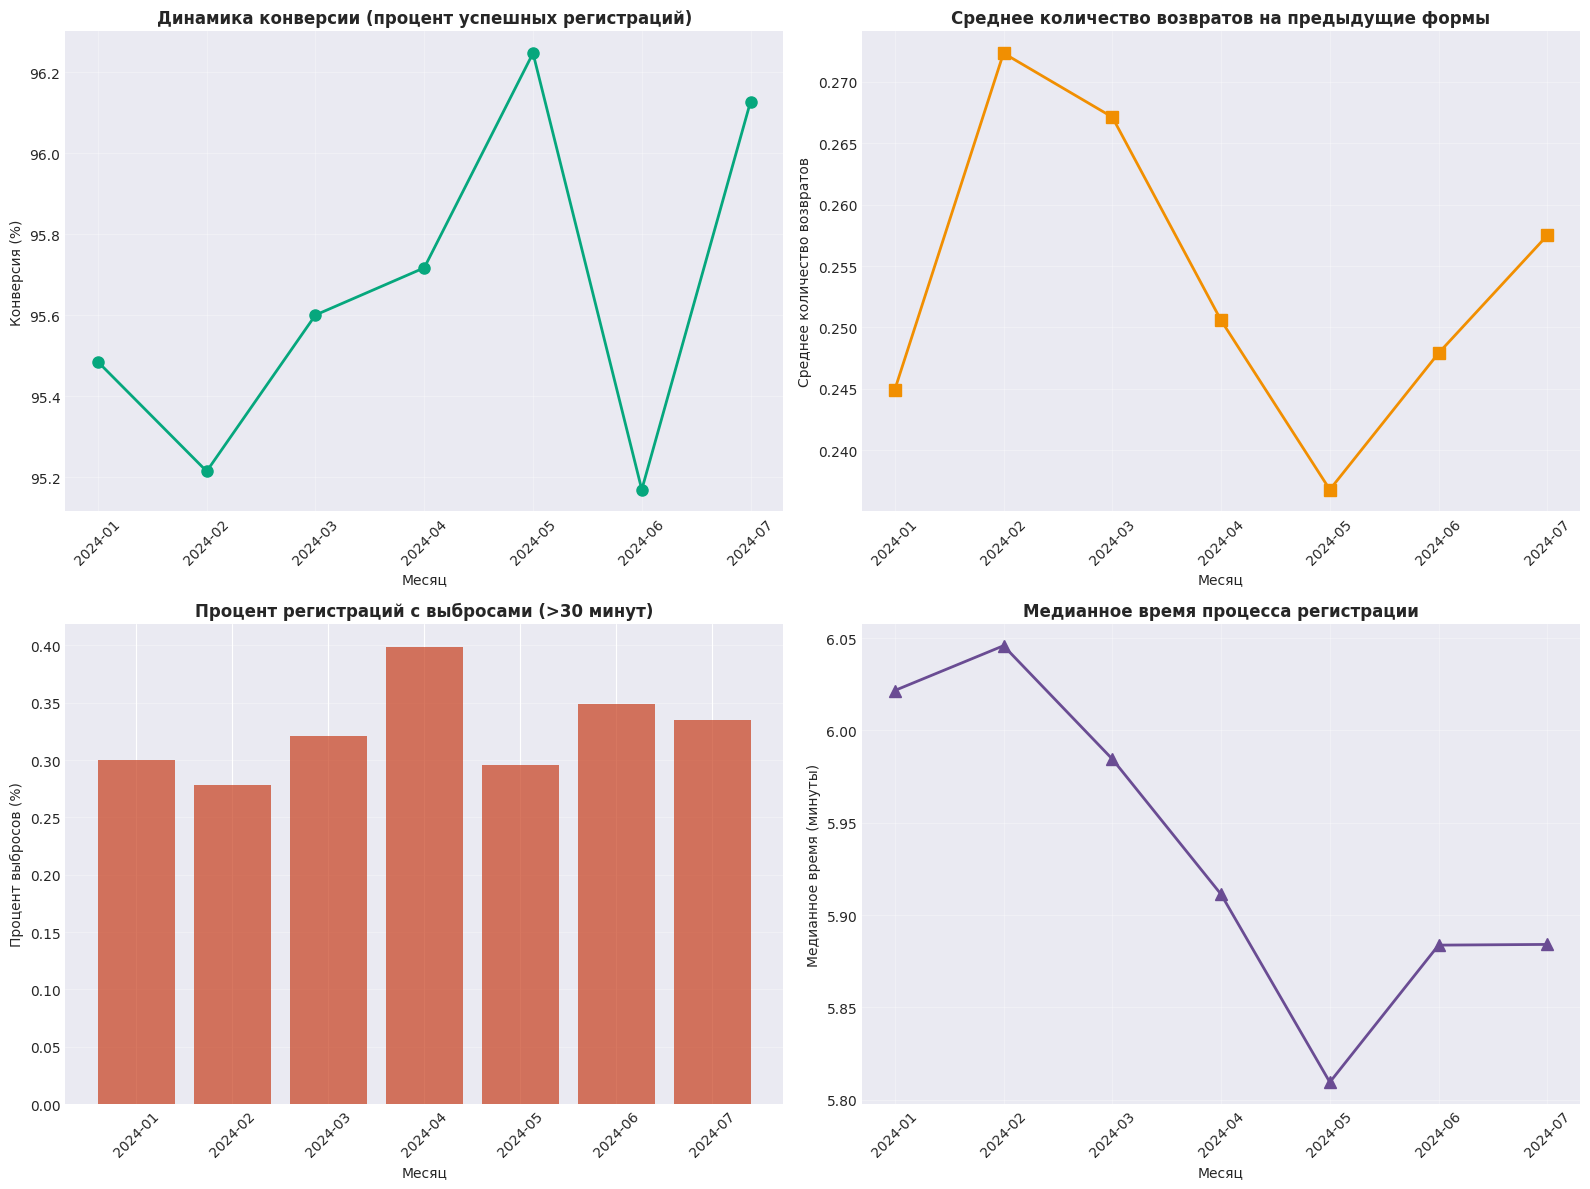

In [68]:
# Визуализация дополнительных метрик
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# График 1: Конверсия
ax1 = axes[0, 0]
ax1.plot(monthly_conversion_df['month'], monthly_conversion_df['conversion_rate'], 
         marker='o', linewidth=2, markersize=8, color='#06A77D')
ax1.set_title('Динамика конверсии (процент успешных регистраций)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Месяц', fontsize=10)
ax1.set_ylabel('Конверсия (%)', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# График 2: Среднее количество возвратов
ax2 = axes[0, 1]
ax2.plot(monthly_returns['month'], monthly_returns['avg_returns'], 
         marker='s', linewidth=2, markersize=8, color='#F18F01')
ax2.set_title('Среднее количество возвратов на предыдущие формы', fontsize=12, fontweight='bold')
ax2.set_xlabel('Месяц', fontsize=10)
ax2.set_ylabel('Среднее количество возвратов', fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

# График 3: Процент выбросов
ax3 = axes[1, 0]
ax3.bar(monthly_outliers['month'], monthly_outliers['outliers_percent'], 
        color='#C73E1D', alpha=0.7)
ax3.set_title('Процент регистраций с выбросами (>30 минут)', fontsize=12, fontweight='bold')
ax3.set_xlabel('Месяц', fontsize=10)
ax3.set_ylabel('Процент выбросов (%)', fontsize=10)
ax3.grid(True, alpha=0.3, axis='y')
ax3.tick_params(axis='x', rotation=45)

# График 4: Медианное время
ax4 = axes[1, 1]
ax4.plot(monthly_median['month'], monthly_median['median_duration_minutes'], 
         marker='^', linewidth=2, markersize=8, color='#6A4C93')
ax4.set_title('Медианное время процесса регистрации', fontsize=12, fontweight='bold')
ax4.set_xlabel('Месяц', fontsize=10)
ax4.set_ylabel('Медианное время (минуты)', fontsize=10)
ax4.grid(True, alpha=0.3)
ax4.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()



## Задание 4: Оценка изменений процесса за 7 месяцев

In [73]:
# Сравнение первого и последнего месяца по ключевым метрикам
first_month = monthly_stats.iloc[0]['month']
last_month = monthly_stats.iloc[-1]['month']

first_data = {
    'month': first_month,
    'registrations': monthly_stats.iloc[0]['successful_registrations'],
    'avg_time': monthly_stats.iloc[0]['avg_duration_minutes'],
    'conversion': monthly_conversion_df[monthly_conversion_df['month'] == first_month]['conversion_rate'].iloc[0],
    'returns': monthly_returns[monthly_returns['month'] == first_month]['avg_returns'].iloc[0],
    'outliers': monthly_outliers[monthly_outliers['month'] == first_month]['outliers_percent'].iloc[0],
    'median_time': monthly_median[monthly_median['month'] == first_month]['median_duration_minutes'].iloc[0]
}

last_data = {
    'month': last_month,
    'registrations': monthly_stats.iloc[-1]['successful_registrations'],
    'avg_time': monthly_stats.iloc[-1]['avg_duration_minutes'],
    'conversion': monthly_conversion_df[monthly_conversion_df['month'] == last_month]['conversion_rate'].iloc[0],
    'returns': monthly_returns[monthly_returns['month'] == last_month]['avg_returns'].iloc[0],
    'outliers': monthly_outliers[monthly_outliers['month'] == last_month]['outliers_percent'].iloc[0],
    'median_time': monthly_median[monthly_median['month'] == last_month]['median_duration_minutes'].iloc[0]
}

comparison_df = pd.DataFrame([first_data, last_data])
print("Сравнение первого и последнего месяца:")
print(comparison_df.to_string(index=False))

Сравнение первого и последнего месяца:
  month  registrations  avg_time  conversion  returns  outliers  median_time
2024-01          14295  6.945129   95.484816 0.244911  0.299902     6.021600
2024-07          20831  6.893615   96.127489 0.257501  0.334912     5.884133


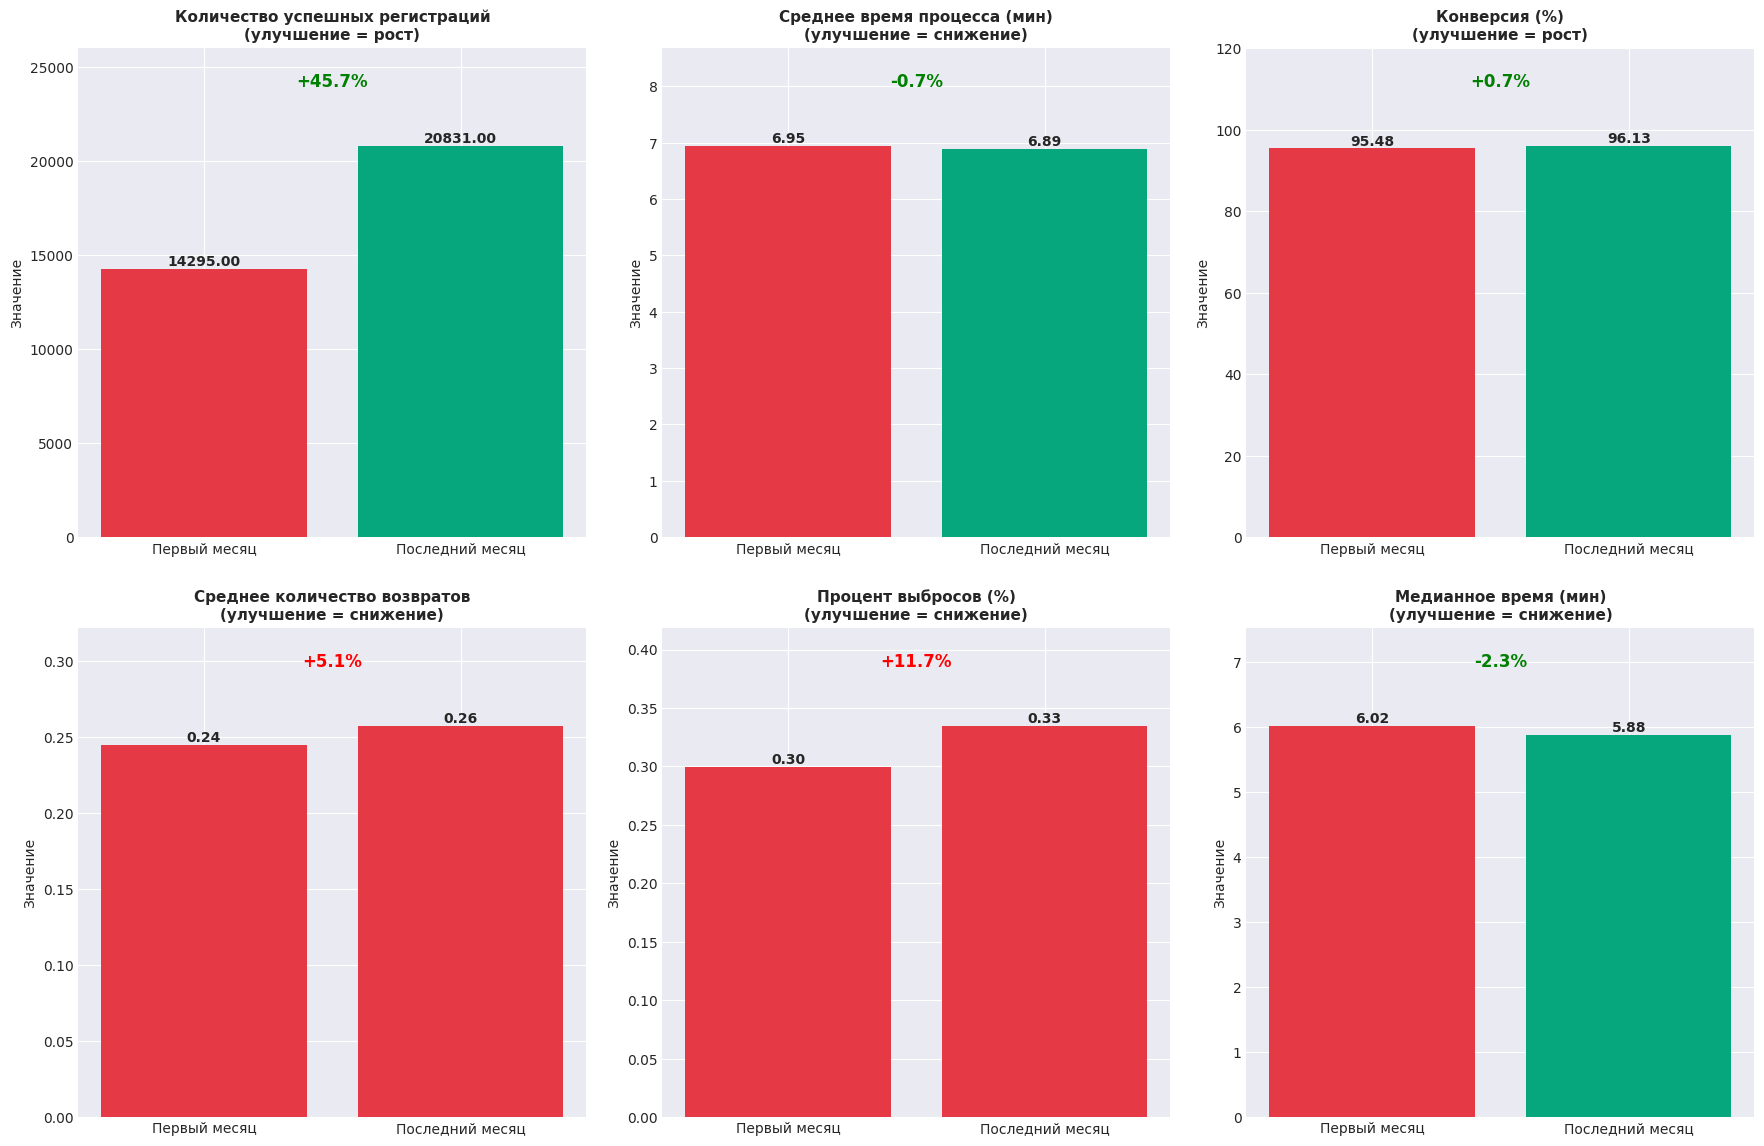

In [72]:
# Расчет изменений в процентах
changes = {}
for metric in ['registrations', 'avg_time', 'conversion', 'returns', 'outliers', 'median_time']:
    first_val = first_data[metric]
    last_val = last_data[metric]
    
    if metric in ['avg_time', 'returns', 'outliers', 'median_time']:
        # Для времени и возвратов - уменьшение это хорошо
        change_pct = ((last_val - first_val) / first_val) * 100
        direction = "улучшение" if change_pct < 0 else "ухудшение"
    else:
        # Для регистраций и конверсии - увеличение это хорошо
        change_pct = ((last_val - first_val) / first_val) * 100
        direction = "улучшение" if change_pct > 0 else "ухудшение"
    
    changes[metric] = {
        'first': first_val,
        'last': last_val,
        'change_pct': change_pct,
        'direction': direction
    }

# Визуализация сравнения
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

metrics_info = [
    ('registrations', 'Количество успешных регистраций', 'улучшение = рост'),
    ('avg_time', 'Среднее время процесса (мин)', 'улучшение = снижение'),
    ('conversion', 'Конверсия (%)', 'улучшение = рост'),
    ('returns', 'Среднее количество возвратов', 'улучшение = снижение'),
    ('outliers', 'Процент выбросов (%)', 'улучшение = снижение'),
    ('median_time', 'Медианное время (мин)', 'улучшение = снижение')
]

for idx, (metric, title, note) in enumerate(metrics_info):
    ax = axes[idx]
    change_info = changes[metric]
    
    bars = ax.bar(['Первый месяц', 'Последний месяц'], 
                  [change_info['first'], change_info['last']],
                  color=['#E63946', '#06A77D'] if change_info['direction'] == 'улучшение' else ['#E63946', '#E63946'])
    
    ax.set_title(f'{title}\n({note})', fontsize=11, fontweight='bold')
    ax.set_ylabel('Значение', fontsize=10)
    
    # Добавление значений на столбцы
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # Получаем максимальное значение для расчета позиции текста
    max_value = max(change_info['first'], change_info['last'])
    
    # Увеличиваем верхний лимит оси Y, чтобы освободить место для текста процентов
    # Это предотвратит наложение на заголовок
    current_ylim = ax.get_ylim()
    new_ymax = max(current_ylim[1], max_value * 1.25)  # 25% отступ сверху от максимального значения
    ax.set_ylim(top=new_ymax)
    
    # Добавление процента изменения - размещаем выше столбцов
    change_text = f"{change_info['change_pct']:+.1f}%"
    color = 'green' if change_info['direction'] == 'улучшение' else 'red'
    
    # Позиционируем текст в середине между столбцами по X, и выше максимального значения по Y
    # X координата: индекс 0.5 (между первым и вторым столбцом, которые имеют индексы 0 и 1)
    # Y координата: 15% выше максимального столбца
    text_x_position = 0.5  # Середина между двумя столбцами (индексы 0 и 1)
    text_y_position = max_value * 1.15  # 15% выше максимального столбца
    
    ax.text(text_x_position, text_y_position, 
            change_text, ha='center', fontsize=12, fontweight='bold', color=color)

# Увеличиваем отступы сверху, чтобы текст процентов и заголовки не накладывались
plt.tight_layout(pad=2.0, h_pad=2.5, w_pad=1.5)
plt.subplots_adjust(top=0.93)  # Дополнительный отступ сверху для заголовков
plt.show()


## Задание 5: Дополнительные инсайты для владельца продукта

In [76]:
# 2. Анализ паттернов возвратов (векторизованно, на выборке)
# Берём случайную выборку кейсов (не более 1000) для ручной проверки паттернов возвратов
sample_size = min(1000, len(case_times_df_filtered))
sample_ids = case_times_df_filtered['case_id'].sample(sample_size, random_state=42).tolist()

# Фильтруем события для выборки и только по экранным формам
sample_step_events = df[df['case_id'].isin(sample_ids) & df['event_category'].isin(steps_dict.keys())].copy()

if sample_step_events.empty:
    print("Недостаточно данных для анализа паттернов возвратов")
else:
    sample_step_events = sample_step_events.sort_values(['case_id', 'timestamp'])
    sample_step_events['step_order'] = sample_step_events['event_category'].map(lambda x: steps_dict[x]['order'])

    # Предыдущее событие в пределах case_id
    sample_step_events['prev_event'] = sample_step_events.groupby('case_id')['event_category'].shift(1)
    sample_step_events['prev_order'] = sample_step_events.groupby('case_id')['step_order'].shift(1)

    # Возврат считается, если текущий порядок меньше предыдущего
    returns_mask = sample_step_events['step_order'] < sample_step_events['prev_order']
    returns_df_sample = sample_step_events.loc[returns_mask, ['case_id', 'event_category', 'prev_event']].rename(
        columns={'event_category': 'return_to_step', 'prev_event': 'return_from_step'})

    if returns_df_sample.empty:
        print("Нет обнаруженных возвратов в выборке")
    else:
        # Частота возвратов на форму (куда возвращаются)
        return_to_counts = returns_df_sample['return_to_step'].value_counts()

        print("\nФормы, на которые чаще всего возвращаются:")
        for step_id, count in return_to_counts.head(5).items():
            print(f"   {steps_dict[step_id]['name']}: {int(count)} возвратов")

        # Топ пар (откуда -> куда)
        pair_counts = returns_df_sample.groupby(['return_from_step', 'return_to_step']).size().sort_values(ascending=False).head(10)
        print("\nТоп пар возвратов (откуда -> куда):")
        for (from_step, to_step), cnt in pair_counts.items():
            print(f"   {steps_dict[from_step]['name']} -> {steps_dict[to_step]['name']}: {int(cnt)} раз")

        # Сохранение для возможного дальнейшего анализа
        return_patterns_df = returns_df_sample.copy()



Формы, на которые чаще всего возвращаются:
   Персональные данные: 52 возвратов
   Резидент или информация о нерезиденте: 45 возвратов
   Идентификация паспортных данных: 29 возвратов
   Моментальная выдача карты: 24 возвратов
   Заказ именных карт: 23 возвратов

Топ пар возвратов (откуда -> куда):
   Адреса -> Резидент или информация о нерезиденте: 45 раз
   Идентификация паспортных данных -> Персональные данные: 40 раз
   Резидент или информация о нерезиденте -> Идентификация паспортных данных: 29 раз
   Проверка данных и подписание черновика -> Моментальная выдача карты: 24 раз
   Моментальная выдача карты -> Заказ именных карт: 21 раз
   Занятость -> Адреса: 19 раз
   ПУ и счета -> Контактная информация: 17 раз
   Контактная информация -> Занятость: 16 раз
   Заказ именных карт -> ПУ и счета: 15 раз
   Резидент или информация о нерезиденте -> Персональные данные: 6 раз


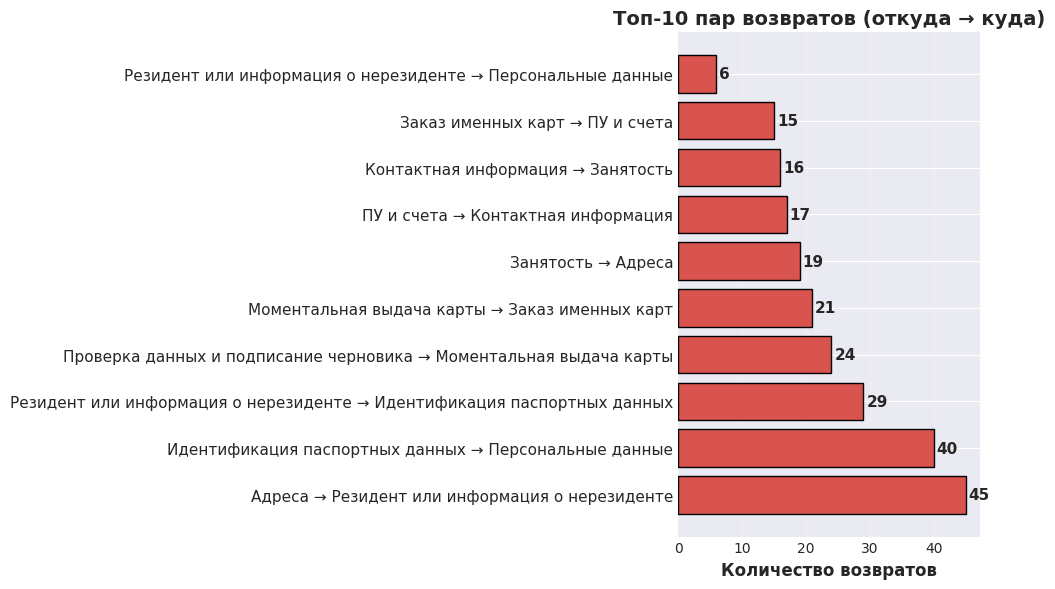

In [80]:


# Собираем топ-10 пар (откуда -> куда)
pair_counts = returns_df_sample.groupby(['return_from_step', 'return_to_step']).size().sort_values(ascending=False).head(10)

labels = []
values = []
for (from_step, to_step), cnt in pair_counts.items():
    from_name = steps_dict.get(from_step, {}).get('name', str(from_step))
    to_name = steps_dict.get(to_step, {}).get('name', str(to_step))
    labels.append(f"{from_name} → {to_name}")
    values.append(int(cnt))

# Если нет данных — аккуратно сообщаем
if len(values) == 0:
    print('\nНет обнаруженных пар возвратов в выборке.')
else:
    fig, ax = plt.subplots(figsize=(10, 6))
    y_pos = range(len(labels))[::-1]  # инвертируем порядок, чтобы лучший был сверху

    bars = ax.barh(y_pos, values[::-1], color='#d9534f', edgecolor='black')

    # Подписи слева с большими метками — делаем читаемыми
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels[::-1], fontsize=11)
    ax.set_xlabel('Количество возвратов', fontsize=12, fontweight='bold')
    ax.set_title('Топ-10 пар возвратов (откуда → куда)', fontsize=14, fontweight='bold')
    ax.grid(axis='x', alpha=0.25)

    # Добавляем числа в конец каждого бара
    for bar in bars:
        w = bar.get_width()
        ax.text(w + max(values)*0.01, bar.get_y() + bar.get_height()/2, f'{int(w)}',
                va='center', fontsize=11, fontweight='bold')

    plt.tight_layout()
    plt.show()

    



Всего уникальных сотрудников: 1257
Среднее количество регистраций на сотрудника: 100.05
Медианное количество регистраций: 73

Топ-10 сотрудников по количеству регистраций:
 employee_id  cases_count
  1331787450          602
   303349872          596
  2308086110          409
  3477558793          408
  3643987715          384
  1186130234          375
  3979133256          370
  3001730245          370
  3299295974          365
  4278005954          362


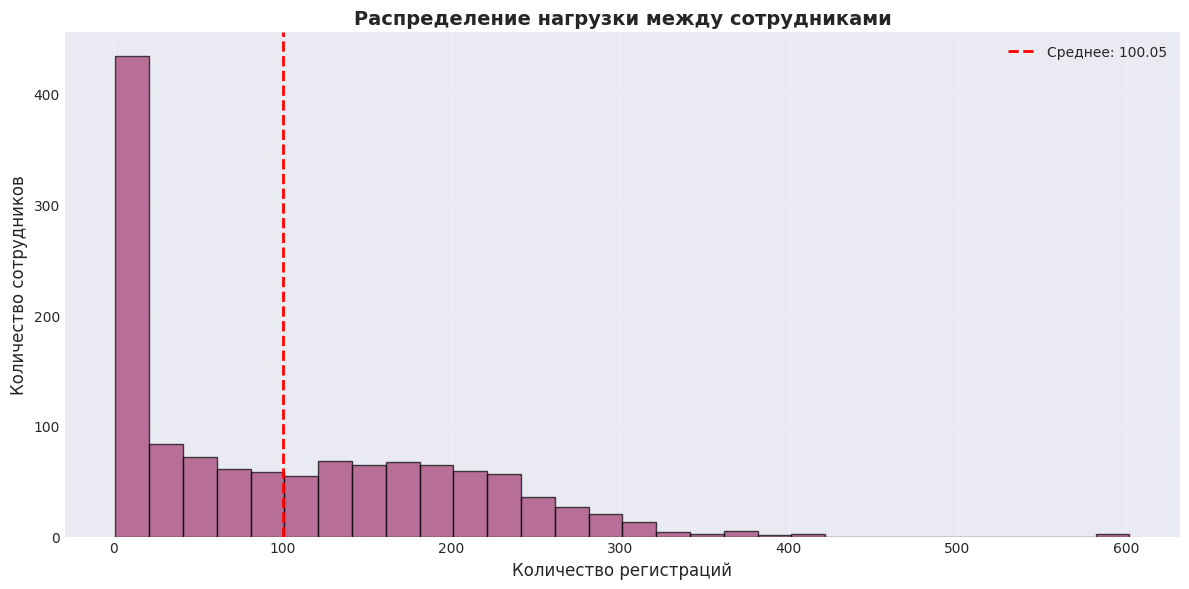

In [82]:
# 4. Анализ эффективности сотрудников
employee_stats = df[df['case_id'].isin(case_times_df_filtered['case_id'])].groupby('employee_id').agg({
    'case_id': 'nunique',
    'timestamp': ['min', 'max']
}).reset_index()

employee_stats.columns = ['employee_id', 'cases_count', 'first_date', 'last_date']
employee_stats = employee_stats.sort_values('cases_count', ascending=False)

print(f"\nВсего уникальных сотрудников: {len(employee_stats)}")
print(f"Среднее количество регистраций на сотрудника: {employee_stats['cases_count'].mean():.2f}")
print(f"Медианное количество регистраций: {employee_stats['cases_count'].median():.0f}")
print(f"\nТоп-10 сотрудников по количеству регистраций:")
print(employee_stats.head(10)[['employee_id', 'cases_count']].to_string(index=False))

# Распределение нагрузки
fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(employee_stats['cases_count'], bins=30, color='#A23B72', alpha=0.7, edgecolor='black')
ax.set_xlabel('Количество регистраций', fontsize=12)
ax.set_ylabel('Количество сотрудников', fontsize=12)
ax.set_title('Распределение нагрузки между сотрудниками', fontsize=14, fontweight='bold')
ax.axvline(employee_stats['cases_count'].mean(), color='red', linestyle='--', 
          linewidth=2, label=f'Среднее: {employee_stats["cases_count"].mean():.2f}')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()